M1-M4 are the assumed models. M5-M12 are observation data-generating processes.

DeepSet, 2*num_dim, 10 observation,DeepSet,epochs=256, inference network: depth=8, widths=(256,256,256), "norm": "layer", larger training budget for M3

In [1]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/opt/anaconda3/envs/benchmark2/bin/../lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file), '/usr/local/lib/libtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache)
INFO:bayesflow:Using backend 'jax'


In [2]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

project_dir = Path("/Users/yimingzang/Documents/thesis/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_dir = project_dir / "results" / "ood_40d_10n"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},

    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},

    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
#pd.DataFrame(source_specs).T

In [3]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [ ]:
# get raw datasets
raw_dataset_dir=project_dir / "results" / "ood_20d_10n"/"datasets"
datasets = {source: load_pickle(raw_dataset_dir / f"{source}_raw.pkl") for source in sd.SOURCE_MODELS}

In [28]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_40d_10n.keras"
filepath_m2 = network_dir / "m2_s_40d_10n.keras"
filepath_m3 = network_dir / "m3_s_40d_10n.keras"
filepath_m4 = network_dir / "m4_s_40d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [ ]:
# Compute logmls and PMPs
calculation_m1 = Calculation(approximator=approximator_m1,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m1",)
calculation_m2 = Calculation(approximator=approximator_m2,mu_prior_mean=3.0,mu_prior_std=1.0,
    num_dims=num_dims,num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m2",)
calculation_m3 = Calculation(approximator=approximator_m3,mu_prior_mean=0.0,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=3.0,num_samples=num_samples,assumed_model="m3",)
calculation_m4 = Calculation(approximator=approximator_m4,mu_prior_mean=0.1,mu_prior_std=1.0,num_dims=num_dims,
    num_obs=num_obs,likelihood_std=1.0,num_samples=num_samples,assumed_model="m4",)

calculations = {"m1": calculation_m1, "m2": calculation_m2, "m3": calculation_m3, "m4": calculation_m4}

In [ ]:
# compute logmls and PMPs for all datasets
datasets = sd.compute_logml_and_posteriors(datasets, calculations)
datasets = sd.compute_model_probabilities(datasets, approximator_direct)

for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_logml_pmp.pkl")

print(datasets["m1"][0].keys())

In [29]:
datasets = {source: load_pickle(dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [30]:
# Fit summary-space reference distributions
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS) 
}
distance_metric = "l2"
references = sd.fit_summary_references(approximators, simulators, n_ref=n_ref, distance_metric=distance_metric,alpha=0.1)
pd.DataFrame({k: {"metric": v["distance_metric"], "summary_dim": v["summary_dim"], "dm_low": v["dm_low"], "dm_high": v["dm_high"], "median": v["median"]} for k, v in references.items()}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,40,0.624726,0.900829,0.731635
m2,l2,40,0.630688,0.898484,0.735602
m3,l2,40,0.585073,0.955047,0.756927
m4,l2,40,0.634698,0.894541,0.736533


In [31]:
# Add dynamic distance regimes and x(y) score
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / "posterior_distance_frame_40d_10n.csv", index=False)
logml_df.to_csv(result_dir / "logml_distance_frame_40d_10n.csv", index=False)
pmp_df.to_csv(result_dir / "pmp_ambiguity_frame_40d_10n.csv", index=False)
logml_summary.to_csv(result_dir / "logml_summary_40d_10n.csv", index=False)
pmp_summary.to_csv(result_dir / "pmp_summary_40d_10n.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_40d_10n.pkl")


In [4]:
# load datasets for plotting
datasets = {source: load_pickle(dataset_dir / f"{source}_processed_40d_10n.pkl") for source in sd.SOURCE_MODELS}
posterior_df = pd.read_csv(result_dir / "posterior_distance_frame_40d_10n.csv")
logml_df = pd.read_csv(result_dir / "logml_distance_frame_40d_10n.csv")
pmp_df = pd.read_csv(result_dir / "pmp_ambiguity_frame_40d_10n.csv")

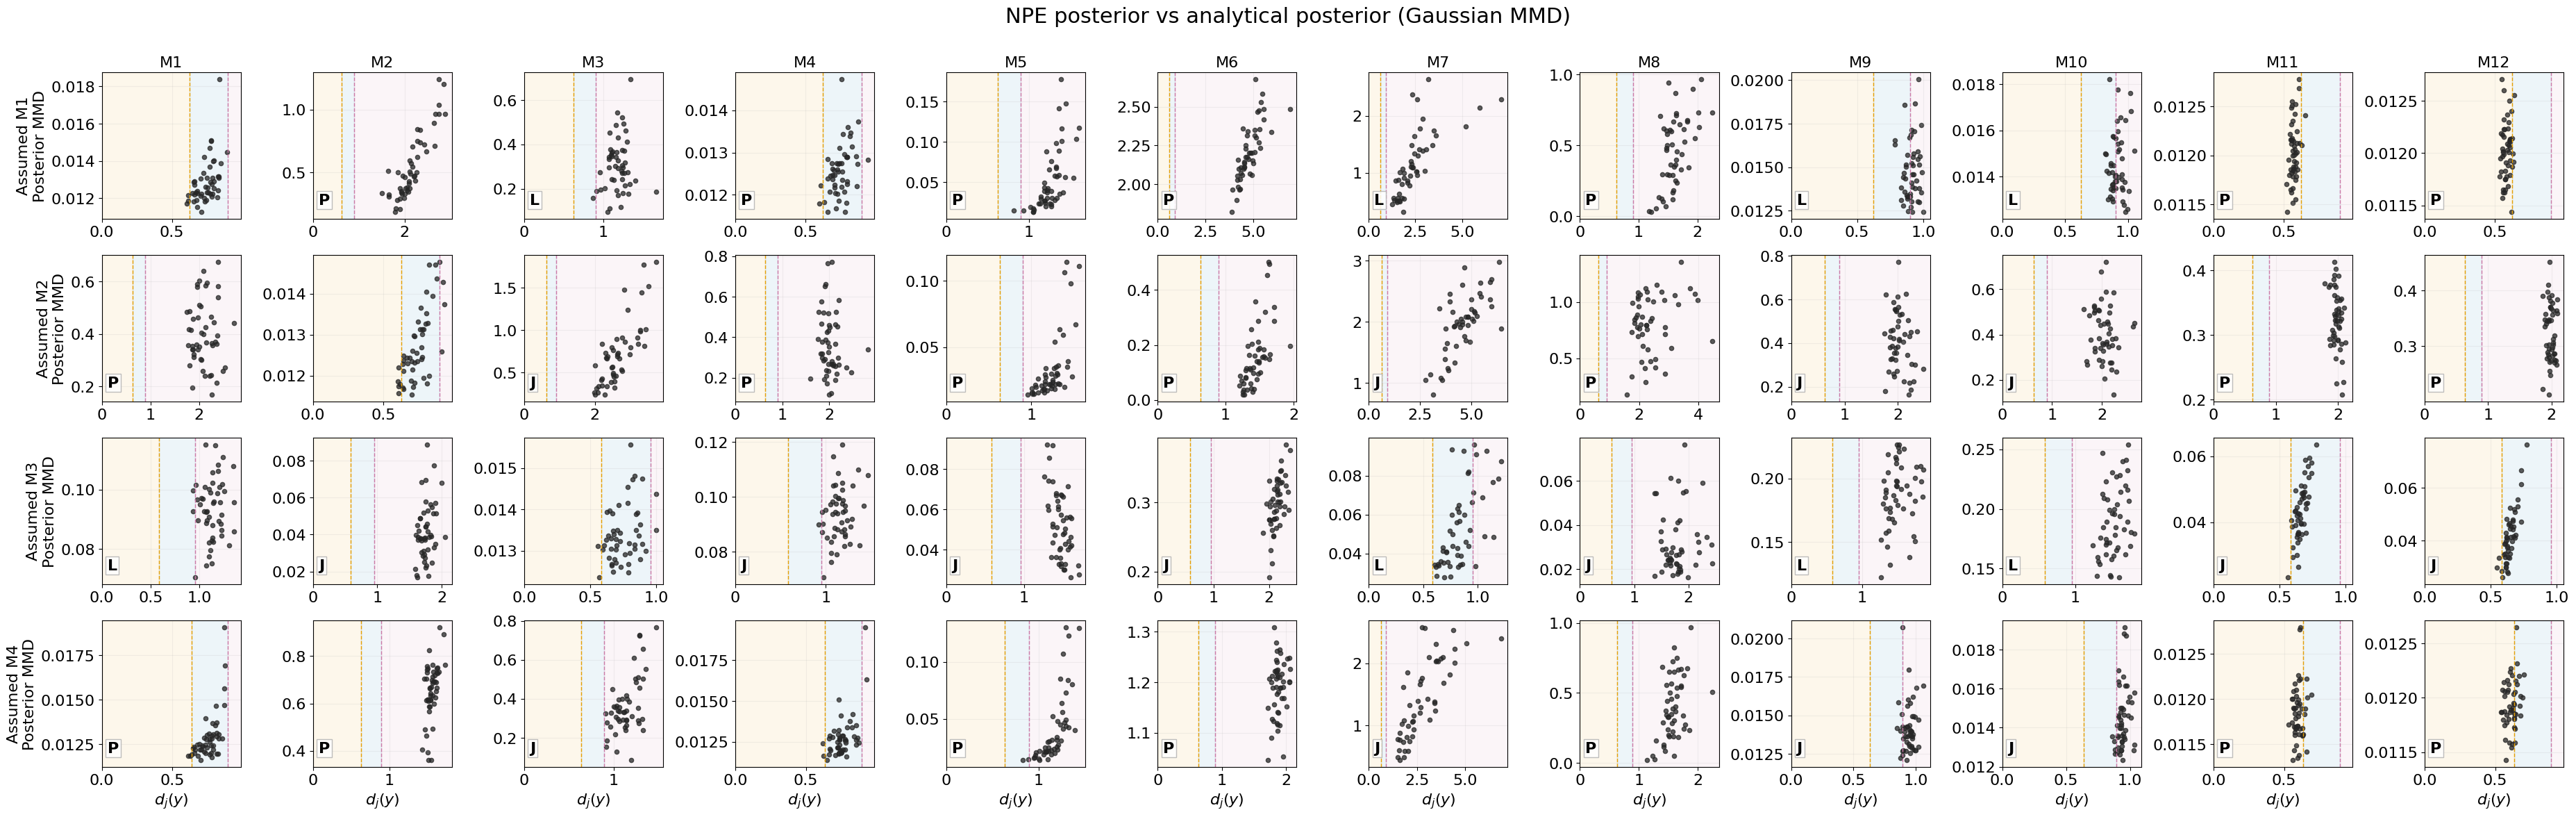

In [33]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mmd", output_dir=figure_dir, sharey=False
);


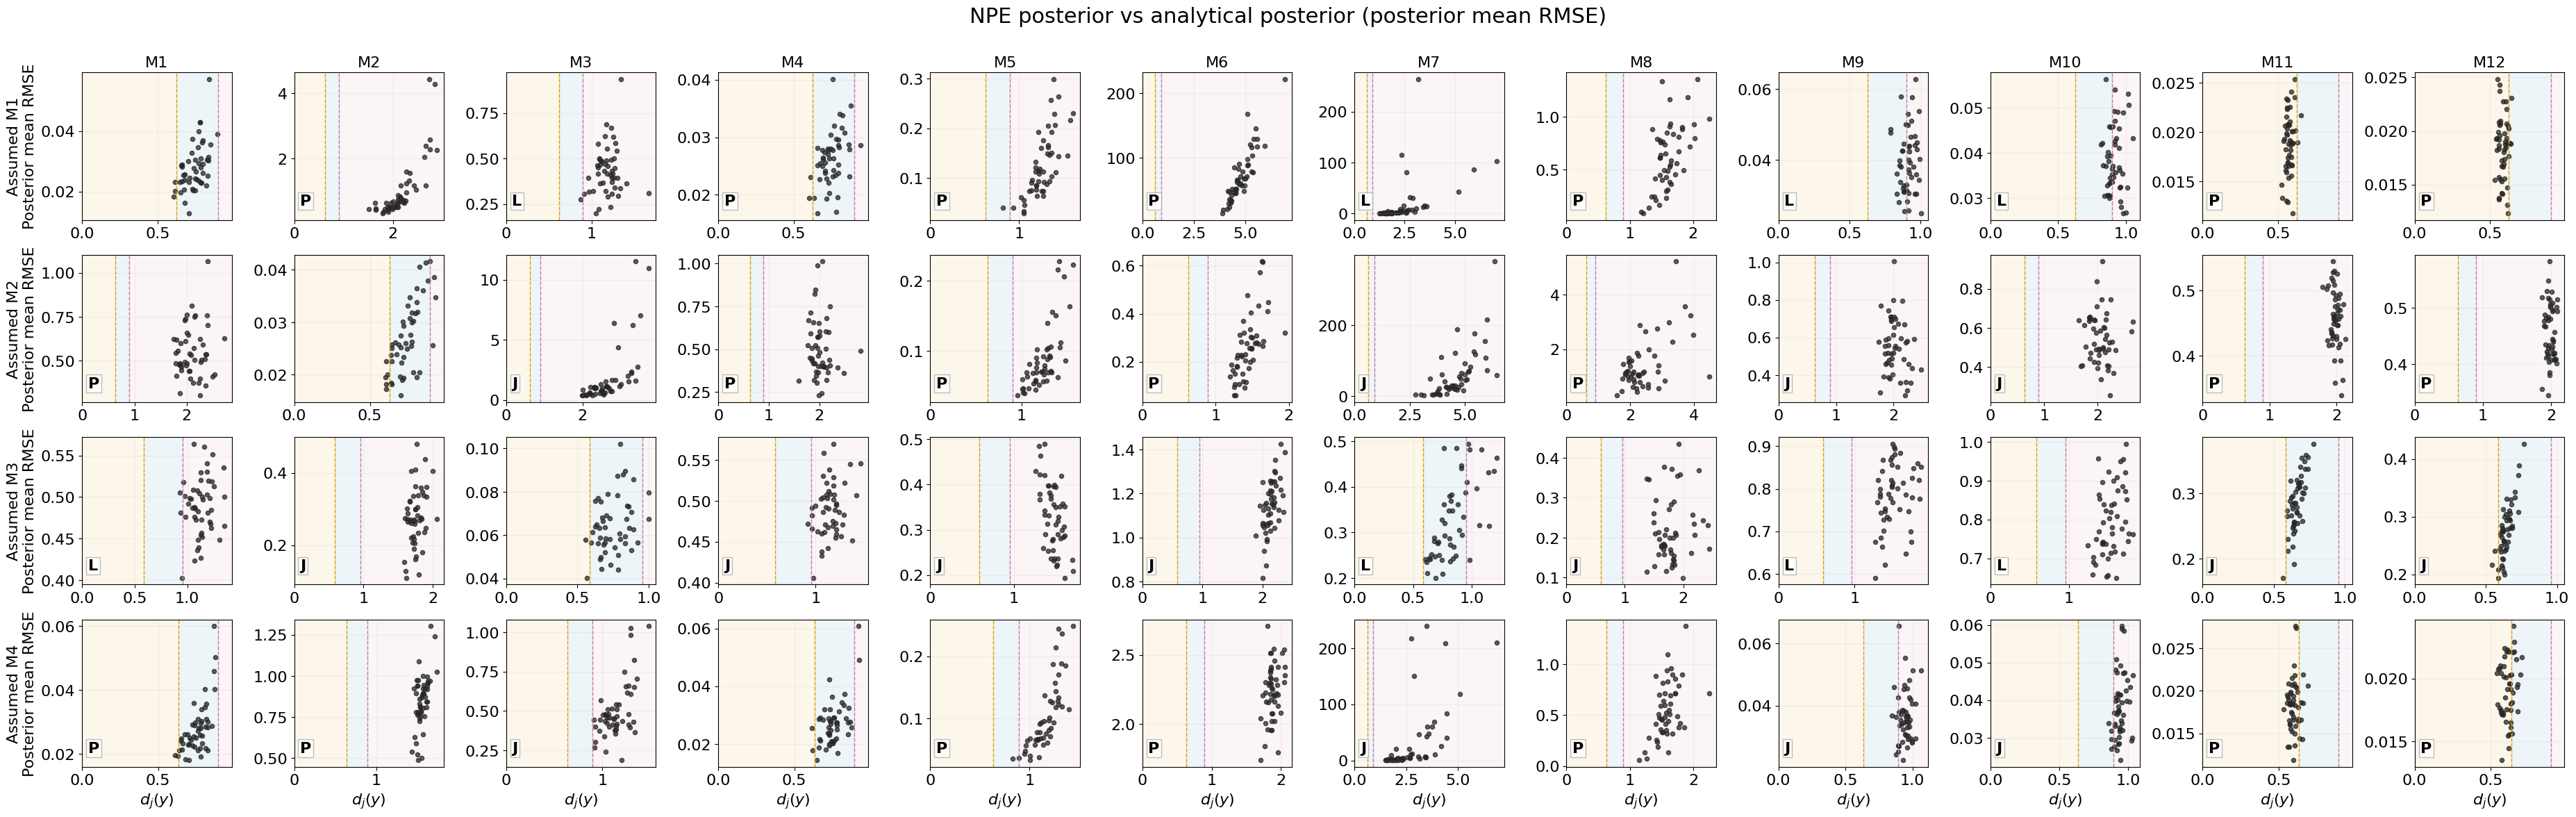

In [34]:
# Posterior RMSE
sd.plot_posterior_metric_grid(
    posterior_df, metric="mean_rmse", output_dir=figure_dir, sharey=False
);


## Plots

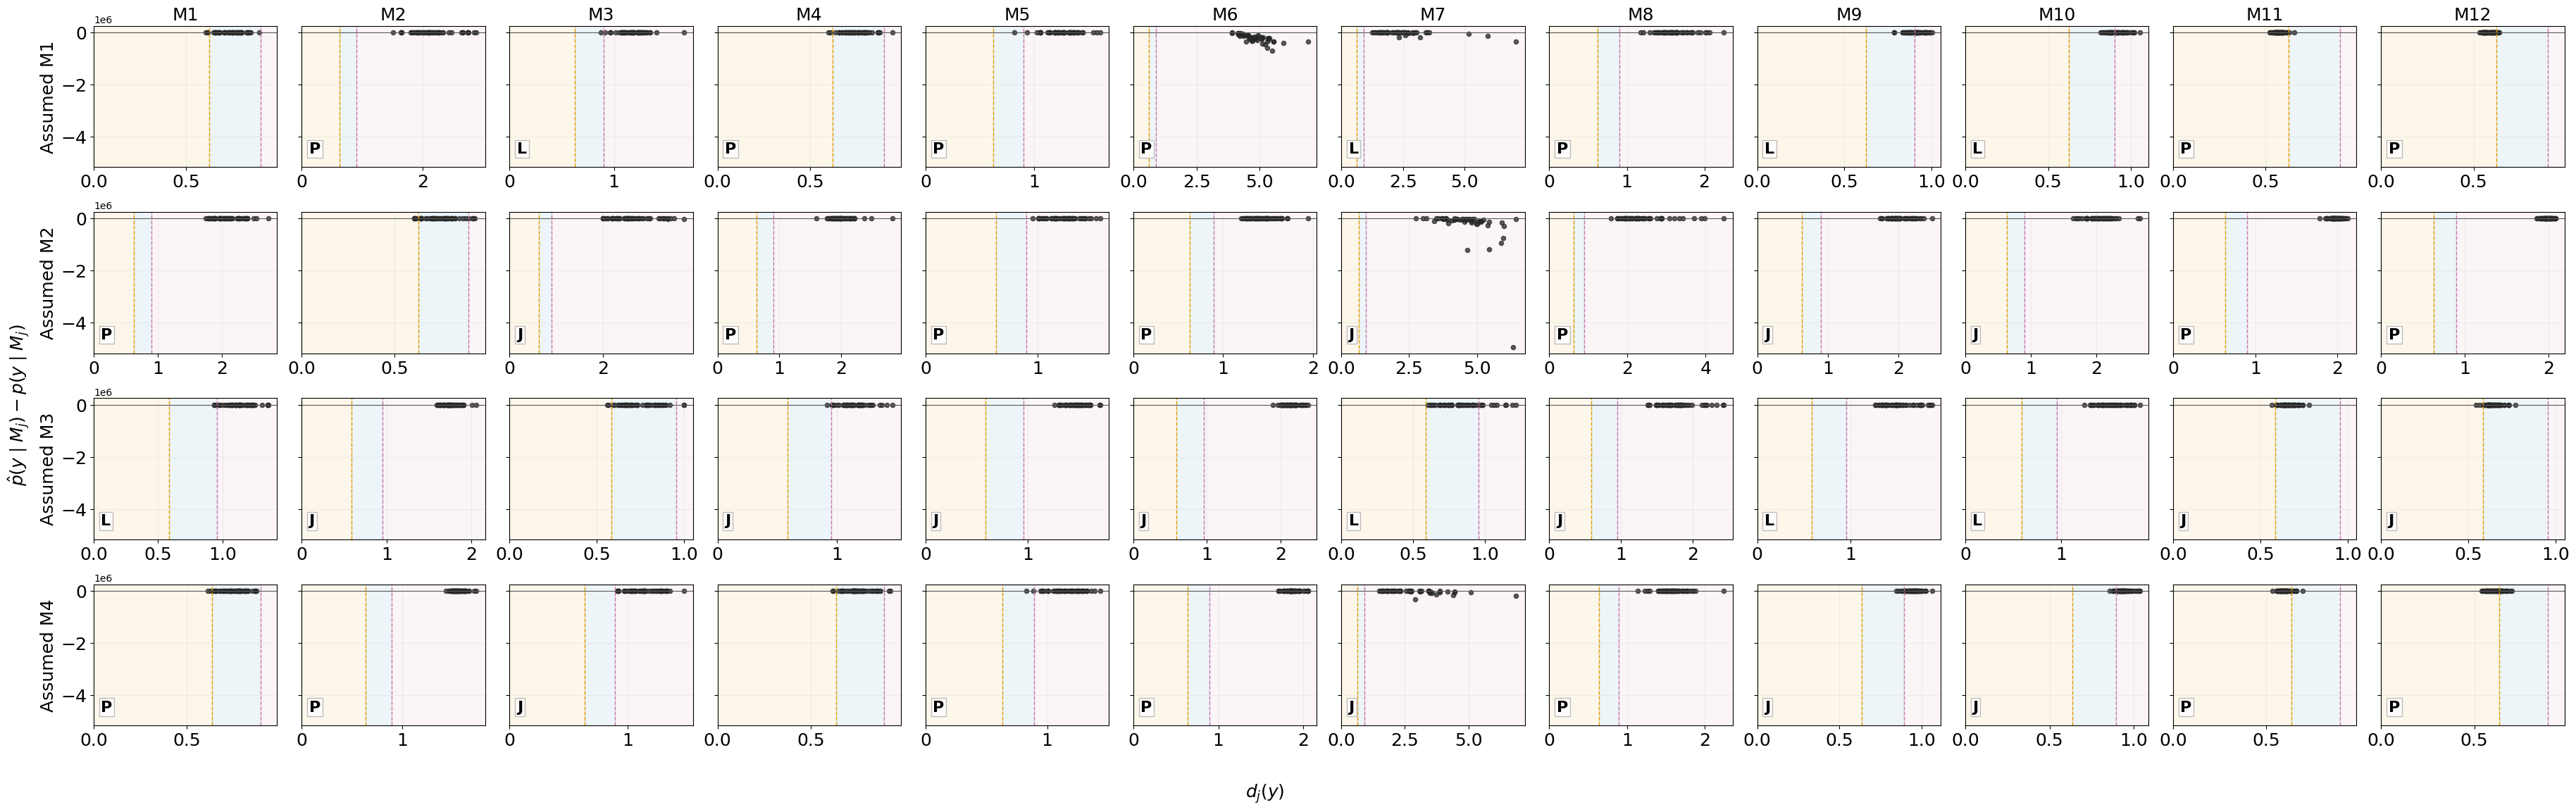

In [5]:
# signed logml error with shared y-axis
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir,error_bound=1000);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

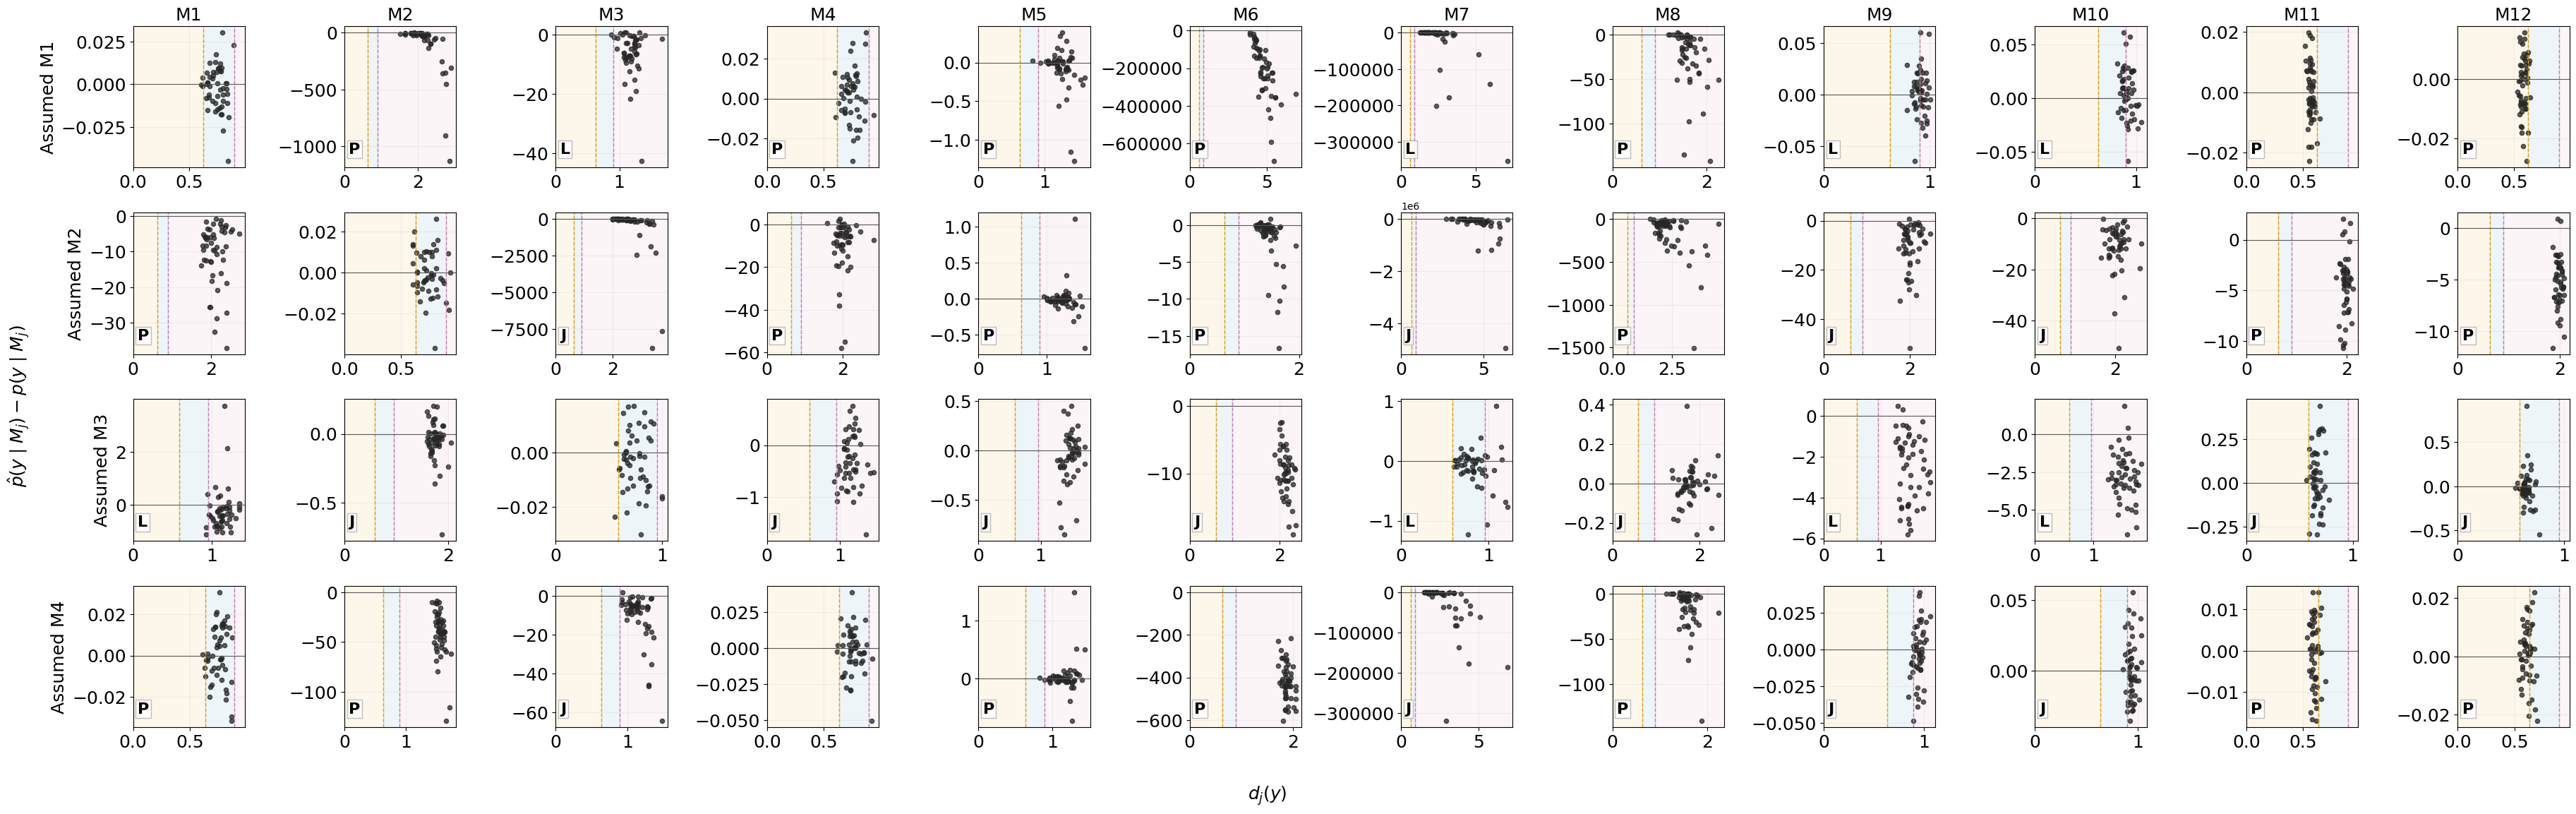

In [6]:
sd.plot_signed_logml_error_grid(logml_df, output_dir=figure_dir,sharey=False);

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\rho_1(y)$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\rho_2(y)$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\rho_3(y)$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\rho_4(y)$'>],
       dtype=object))

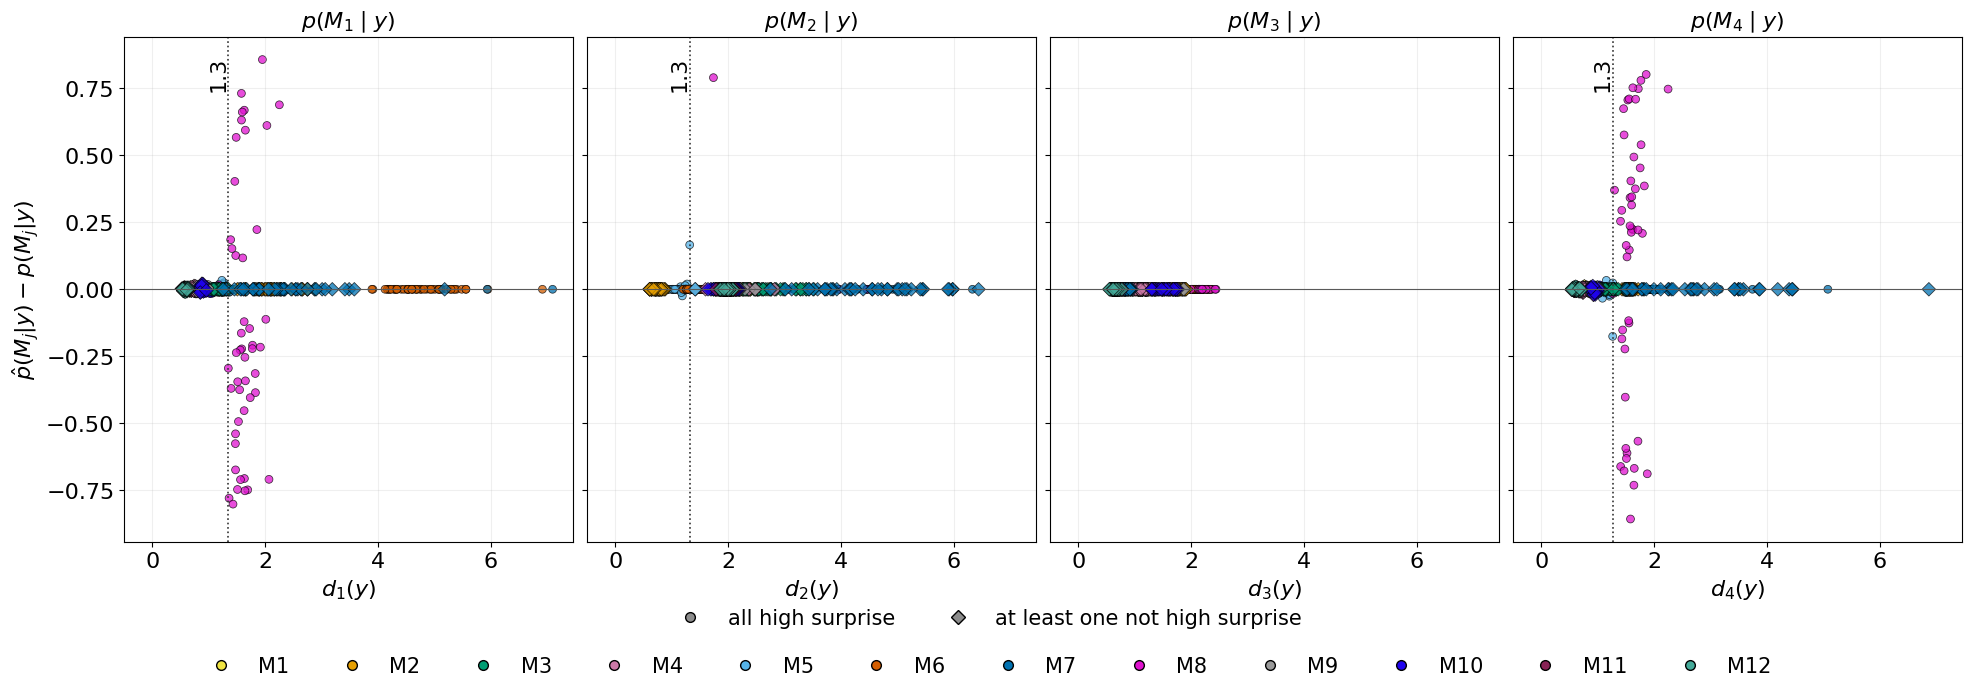

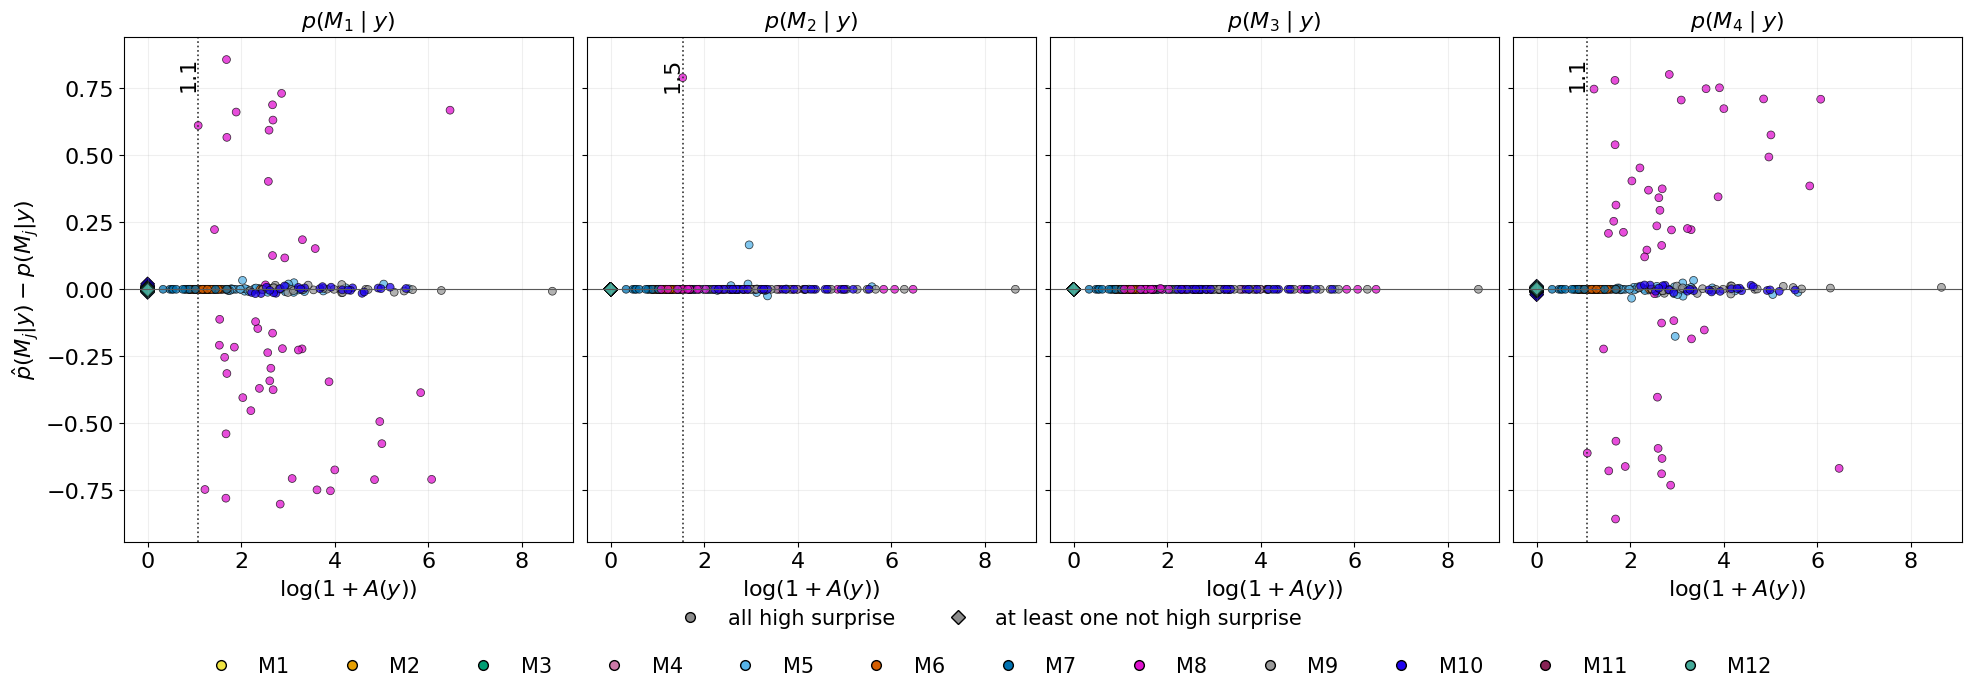

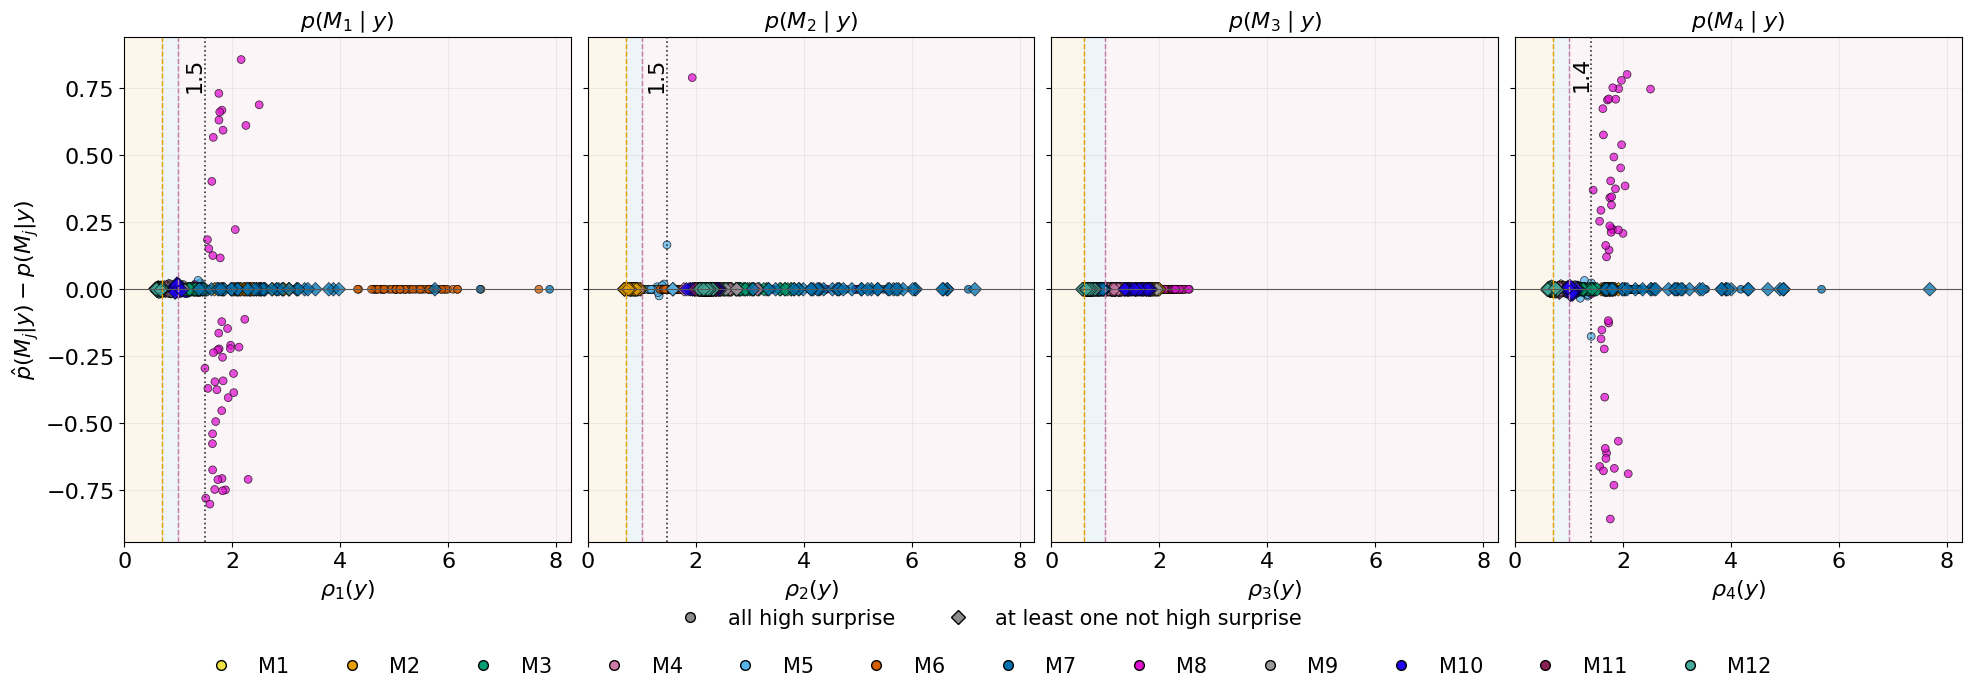

In [7]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df, x="distance", y="signed_error", group_by="global_extrapolation_source", estimate="npe", output_dir=figure_dir, filename="x_vs_pmp_error_npe.png", sharex=True, error_bound=0.05,error_subset="all_extrapolative")
sd.plot_pmp_diagnostic(pmp_df,x="logA",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=figure_dir,filename="pmp_error_global_extrapolation_by_source.png",sharex=True,error_bound=0.05,error_subset="all_extrapolative")

sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,)

(<Figure size 1960x600 with 4 Axes>,
 array([<Axes: title={'center': '$p(M_1\\mid y)$'}, xlabel='$\\rho_1(y)$', ylabel='$\\hat{p}(M_j|y)-p(M_j|y)$'>,
        <Axes: title={'center': '$p(M_2\\mid y)$'}, xlabel='$\\rho_2(y)$'>,
        <Axes: title={'center': '$p(M_3\\mid y)$'}, xlabel='$\\rho_3(y)$'>,
        <Axes: title={'center': '$p(M_4\\mid y)$'}, xlabel='$\\rho_4(y)$'>],
       dtype=object))

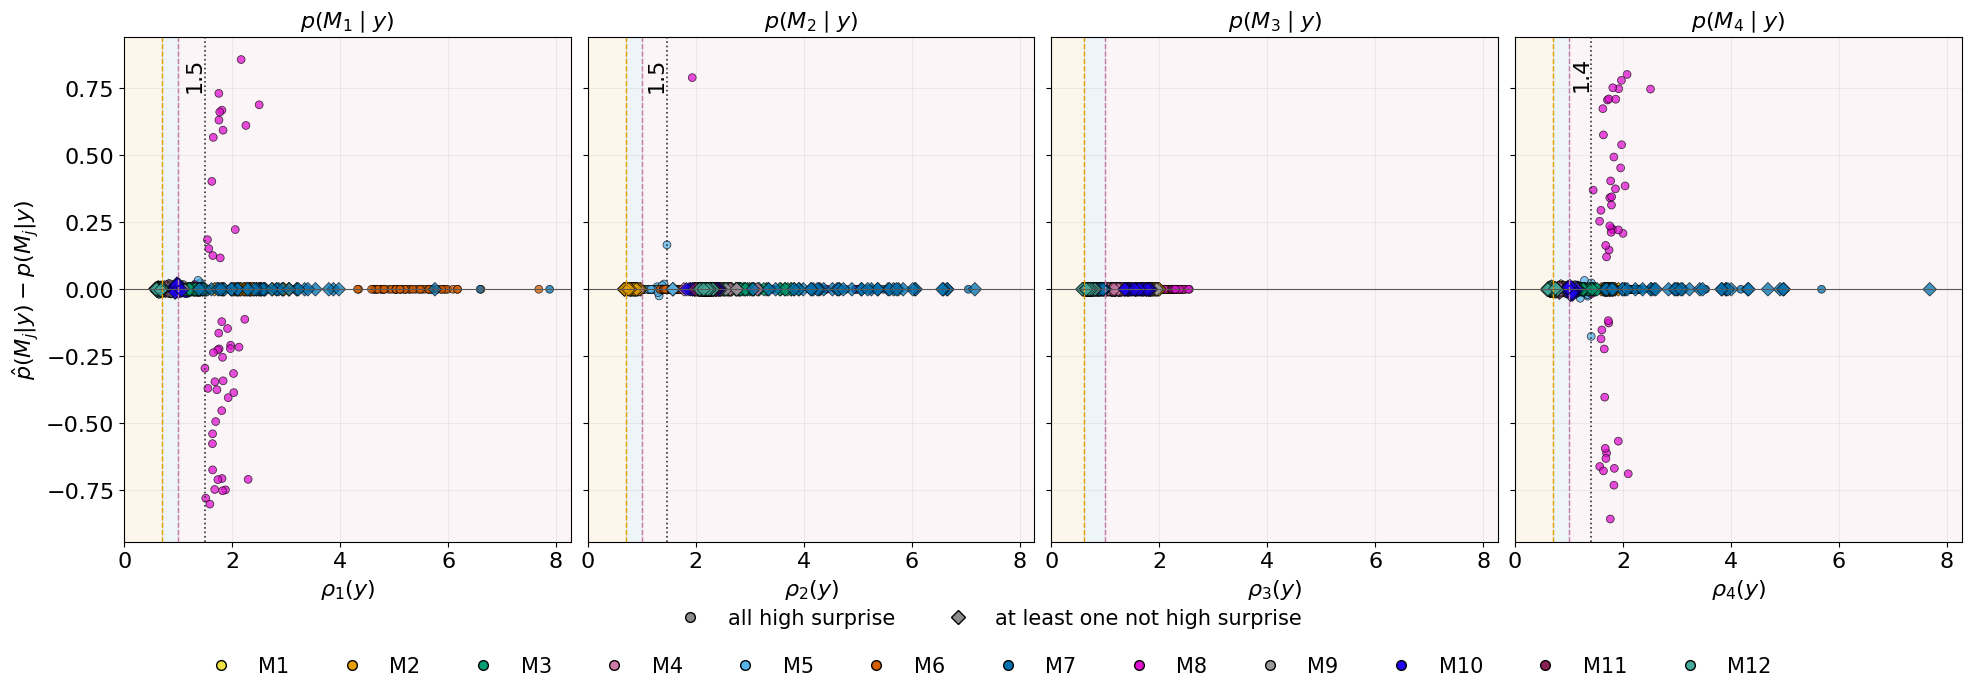

In [5]:
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,)

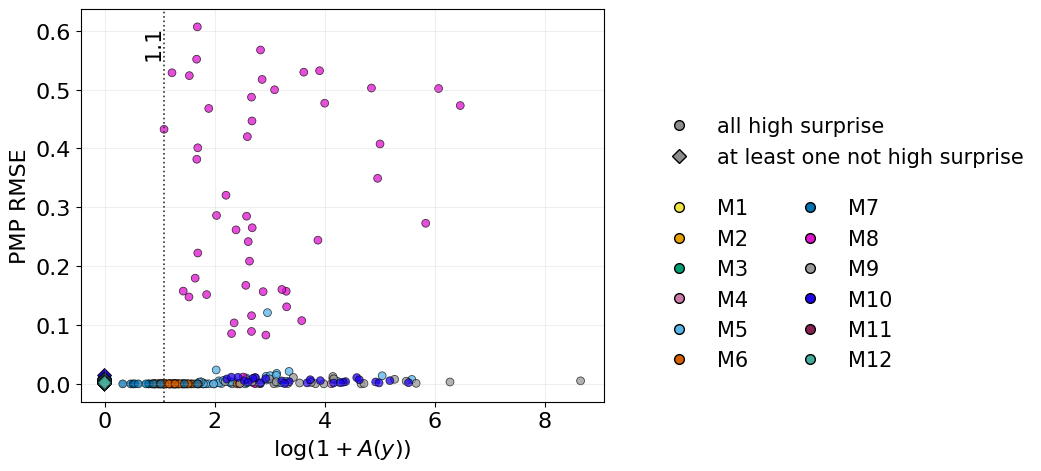

In [5]:

fig, ax = sd.plot_pmp_diagnostic(
    pmp_df,
    x="logA",
    y="rmse",
    group_by="global_extrapolation_source",
    estimate="npe",
    output_dir=None,
    x_min=0.0,
    error_bound=0.05,
)


In [9]:
# Summary tables: NPE PMP error, rho_j(y), and A(y) intervals
summary_rows = []

for source_model in sd.SOURCE_MODELS:
    source_data = pmp_df[pmp_df["source_model"] == source_model]
    A = np.log1p(source_data["ambiguity_score"])

    for assumed_model in sd.ASSUMED_MODELS:
        error = source_data[f"signed_pmp_error_npe_{assumed_model}"]
        rho = (
            source_data[f"d_{assumed_model}"]
            / source_data[f"dm_high_{assumed_model}"]
        )

        summary_rows.append({
            "source_model": source_model.upper(),
            "assumed_model": assumed_model.upper(),
            "error_min": error.min(),
            "error_max": error.max(),
            "rho_min": rho.min(),
            "rho_max": rho.max(),
            "A_min": A.min(),
            "A_max": A.max(),
        })

interval_summary = pd.DataFrame(summary_rows)

def format_interval(low, high):
    return f"[{low:.3f}, {high:.3f}]"

interval_summary["NPE PMP error interval"] = [
    format_interval(low, high)
    for low, high in zip(interval_summary["error_min"], interval_summary["error_max"])
]
interval_summary["rho_j(y) interval"] = [
    format_interval(low, high)
    for low, high in zip(interval_summary["rho_min"], interval_summary["rho_max"])
]

error_interval_table = interval_summary.pivot(
    index="source_model",
    columns="assumed_model",
    values="NPE PMP error interval",
).reindex(index=[model.upper() for model in sd.SOURCE_MODELS])

rho_interval_table = interval_summary.pivot(
    index="source_model",
    columns="assumed_model",
    values="rho_j(y) interval",
).reindex(index=[model.upper() for model in sd.SOURCE_MODELS])

A_interval_table = (
    interval_summary.drop_duplicates("source_model")
    .set_index("source_model")[["A_min", "A_max"]]
    .reindex([model.upper() for model in sd.SOURCE_MODELS])
)
A_interval_table["A(y) interval"] = [
    format_interval(low, high)
    for low, high in zip(A_interval_table["A_min"], A_interval_table["A_max"])
]
A_interval_table = A_interval_table[["A(y) interval"]]

display("NPE PMP signed error intervals", error_interval_table)
display(r"$\rho_j(y)=d_j(y)/d_{j,\mathrm{high}}$ intervals", rho_interval_table)
display(r"$A(y)=\log(1+\mathrm{ambiguity\ score})$ intervals", A_interval_table)


'NPE PMP signed error intervals'

assumed_model,M1,M2,M3,M4
source_model,,,,
M1,"[-0.011, 0.006]","[-0.000, -0.000]","[-0.000, 0.000]","[-0.006, 0.011]"
M2,"[-0.000, 0.000]","[0.000, 0.000]","[-0.000, 0.000]","[-0.000, -0.000]"
M3,"[-0.000, 0.000]","[-0.000, -0.000]","[0.000, 0.000]","[-0.000, 0.000]"
M4,"[-0.005, 0.021]","[-0.000, 0.000]","[-0.000, 0.000]","[-0.021, 0.005]"
M5,"[-0.011, 0.033]","[-0.025, 0.166]","[-0.000, 0.000]","[-0.176, 0.033]"
M6,"[-0.000, -0.000]","[0.000, 0.000]","[-0.000, -0.000]","[-0.000, -0.000]"
M7,"[0.000, 0.000]","[0.000, 0.000]","[0.000, 0.000]","[0.000, 0.000]"
M8,"[-0.802, 0.858]","[-0.000, 0.790]","[-0.000, 0.003]","[-0.858, 0.802]"
M9,"[-0.013, 0.018]","[-0.000, 0.000]","[-0.000, 0.000]","[-0.018, 0.013]"


'$\\rho_j(y)=d_j(y)/d_{j,\\mathrm{high}}$ intervals'

assumed_model,M1,M2,M3,M4
source_model,,,,
M1,"[0.673, 0.993]","[1.940, 3.031]","[0.978, 1.420]","[0.684, 0.978]"
M2,"[1.674, 3.205]","[0.673, 1.039]","[1.665, 2.152]","[1.598, 1.939]"
M3,"[0.969, 1.856]","[2.216, 4.158]","[0.584, 1.047]","[1.018, 1.655]"
M4,"[0.668, 1.049]","[1.779, 3.140]","[0.963, 1.532]","[0.690, 1.038]"
M5,"[0.910, 1.784]","[1.065, 1.735]","[1.323, 1.787]","[0.928, 1.605]"
M6,"[4.323, 7.681]","[1.336, 2.167]","[1.982, 2.486]","[1.912, 2.300]"
M7,"[1.394, 7.881]","[3.060, 7.170]","[0.630, 1.271]","[1.671, 7.683]"
M8,"[1.310, 2.500]","[1.760, 4.973]","[1.439, 2.555]","[1.275, 2.511]"
M9,"[0.872, 1.112]","[1.940, 2.758]","[1.325, 1.958]","[0.948, 1.188]"


'$A(y)=\\log(1+\\mathrm{ambiguity\\ score})$ intervals'

,A(y) interval
source_model,
M1,"[0.000, 0.000]"
M2,"[0.000, 0.974]"
M3,"[0.000, 1.790]"
M4,"[0.000, 4.122]"
M5,"[0.000, 5.585]"
M6,"[0.856, 2.453]"
M7,"[0.000, 1.689]"
M8,"[1.081, 6.466]"
M9,"[0.000, 8.653]"


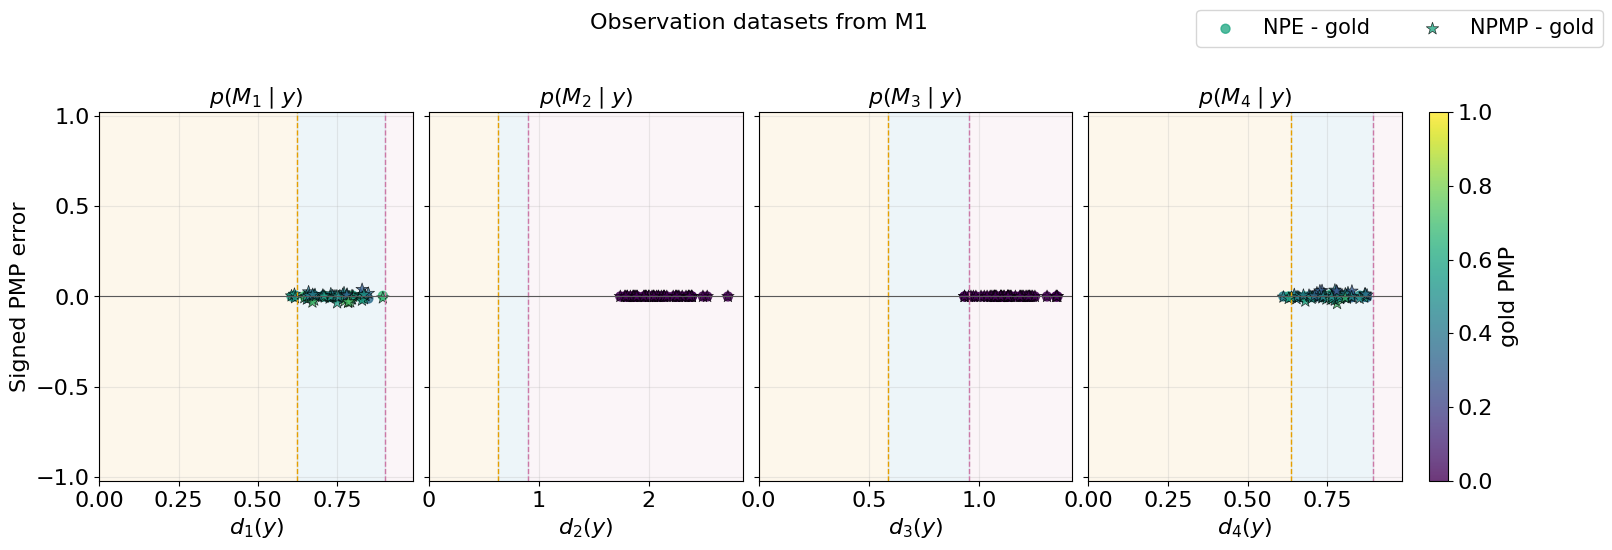

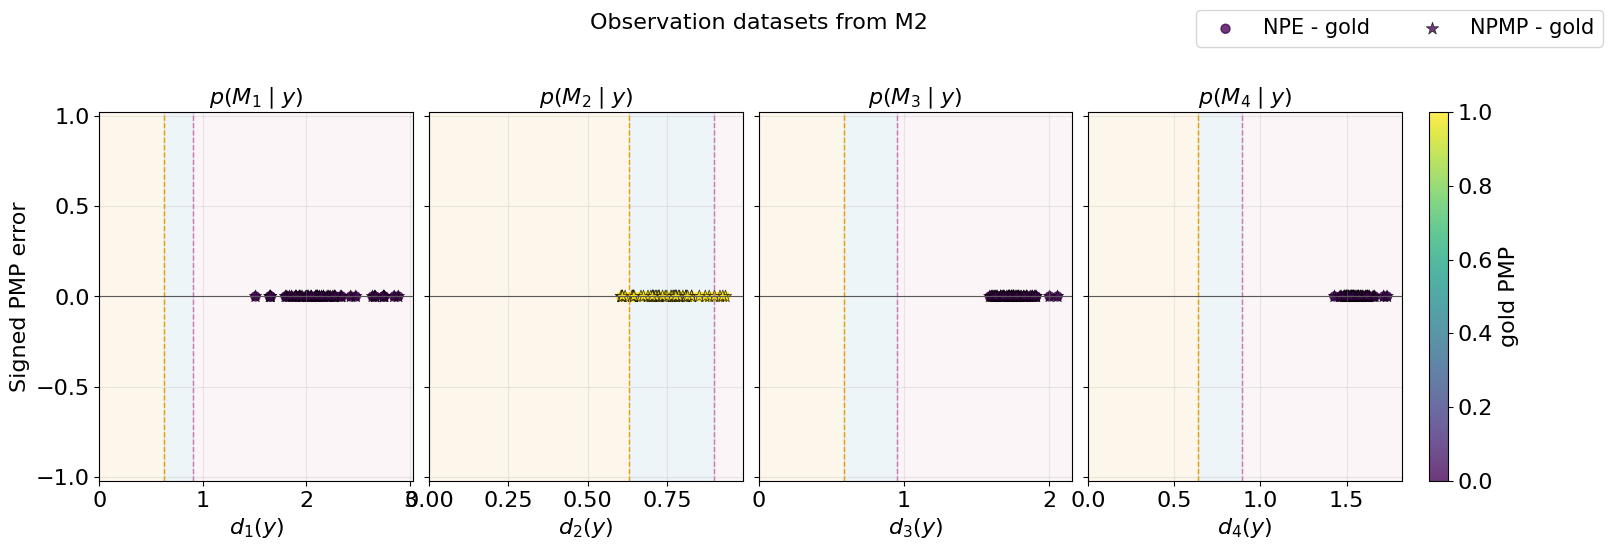

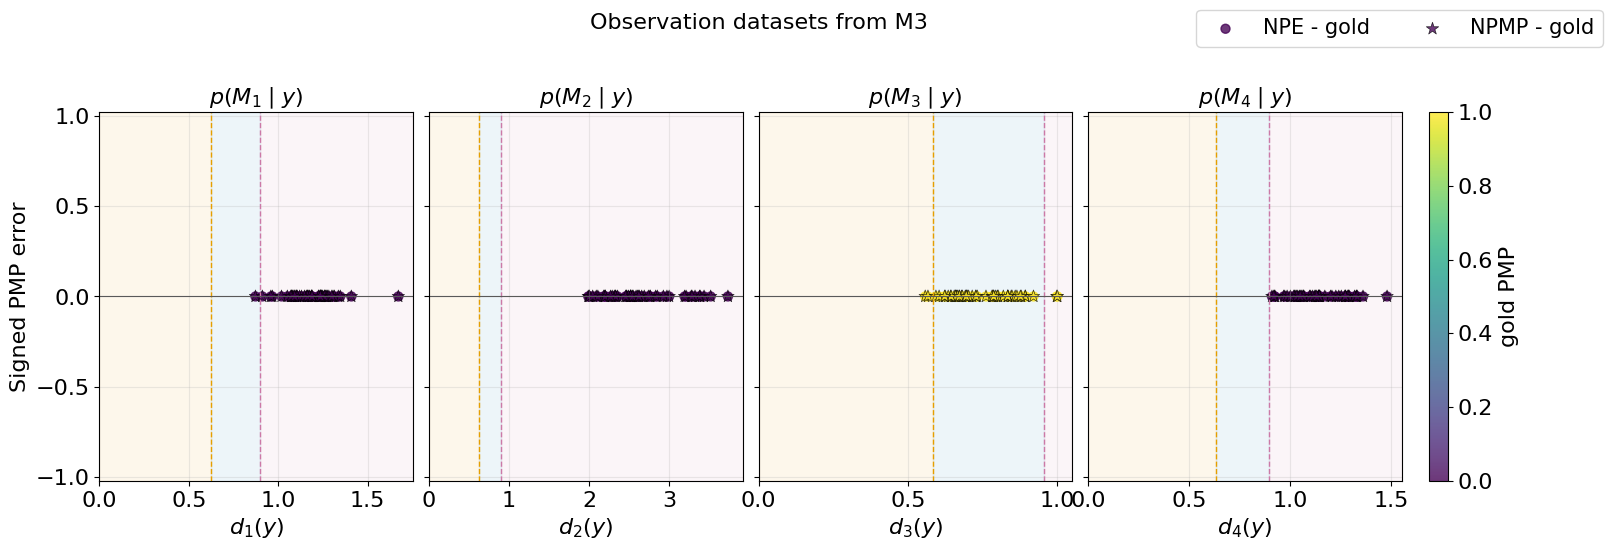

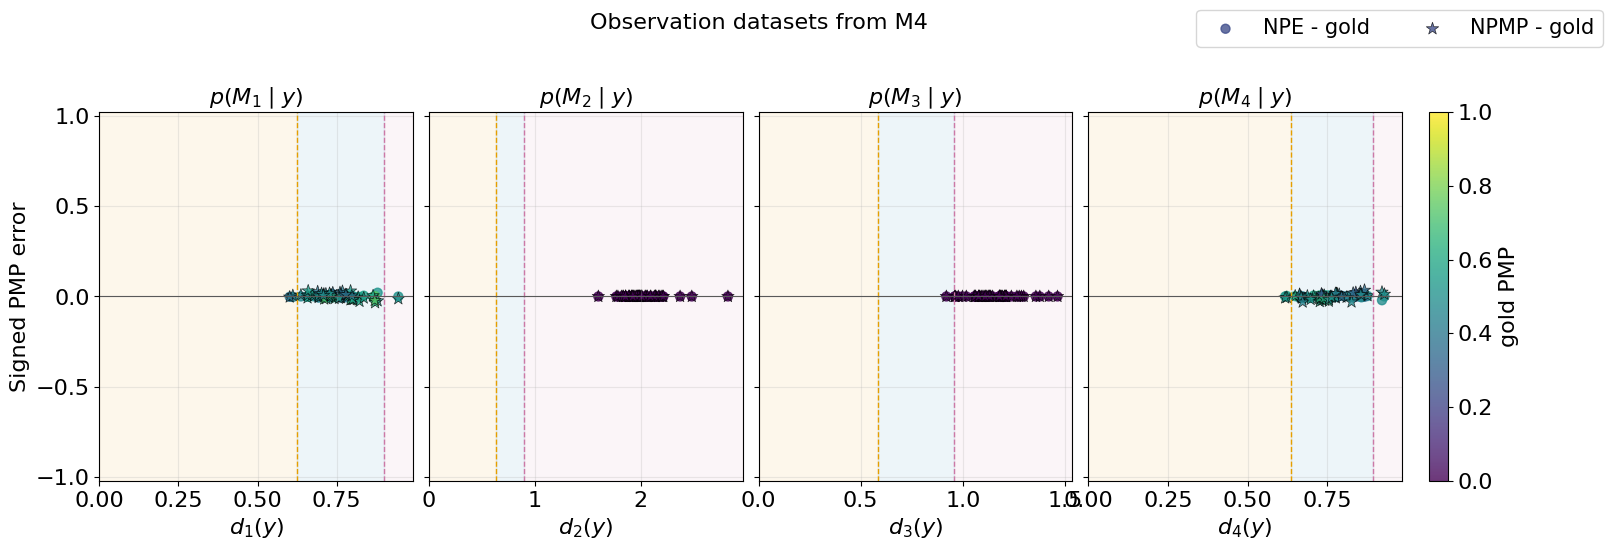

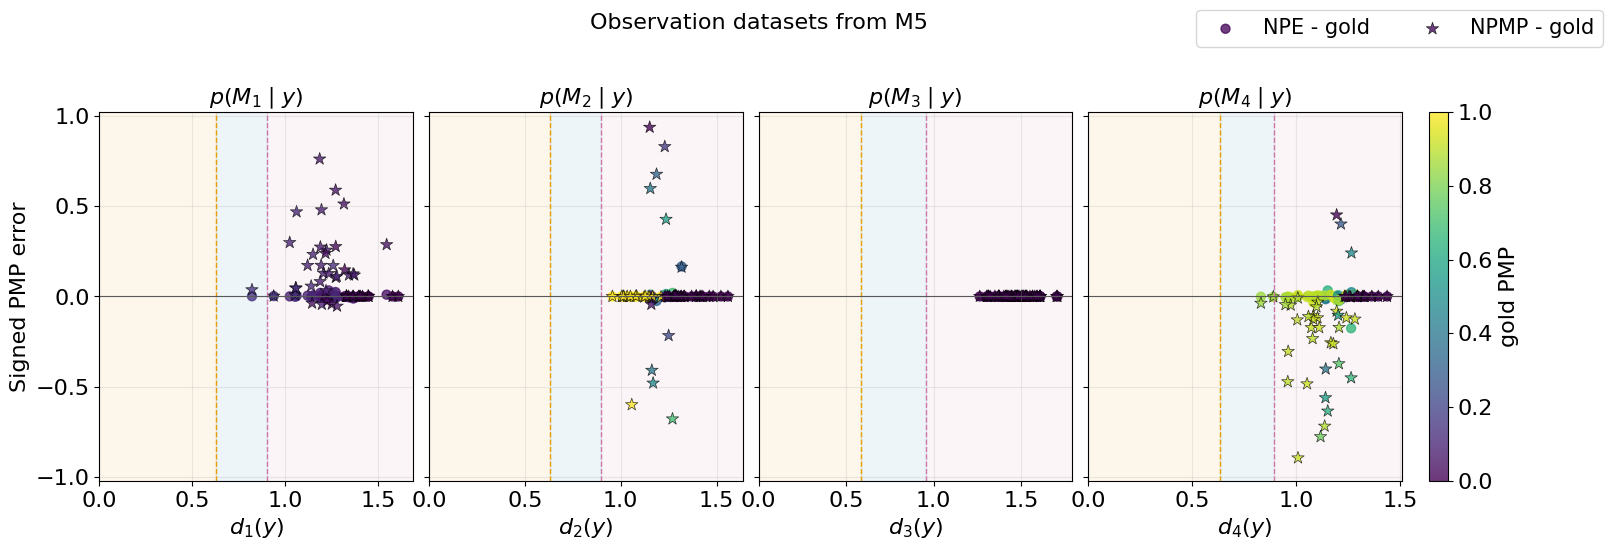

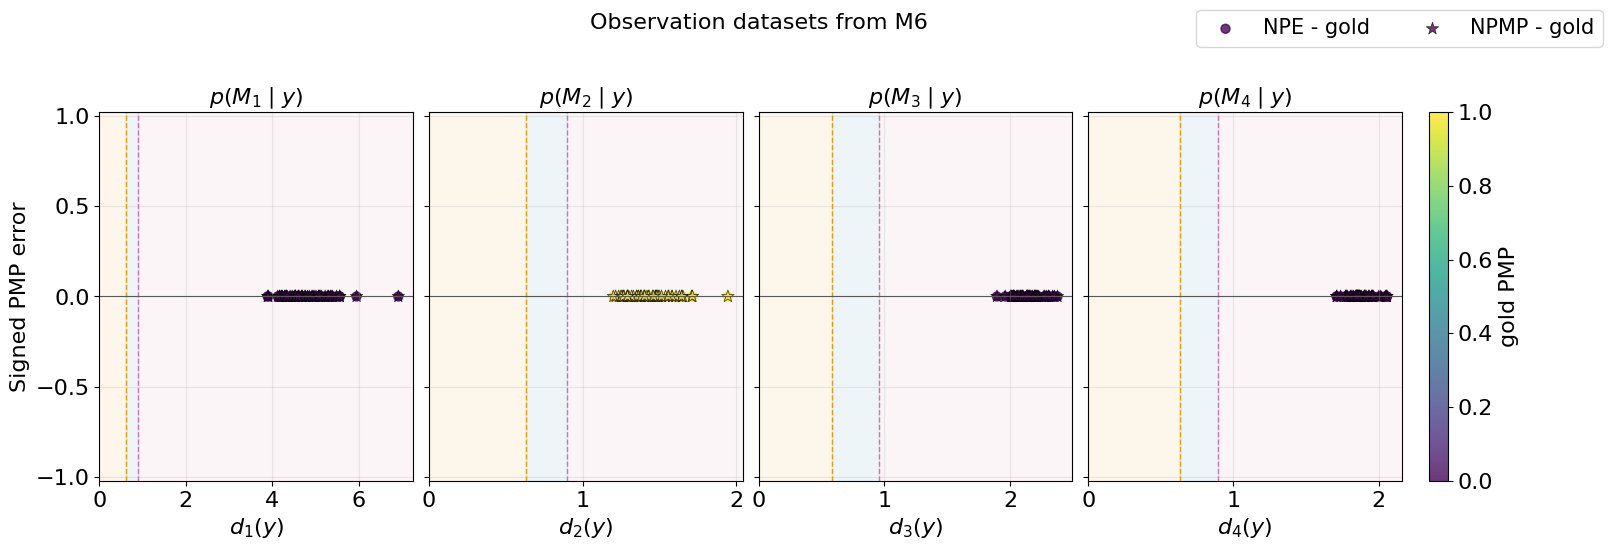

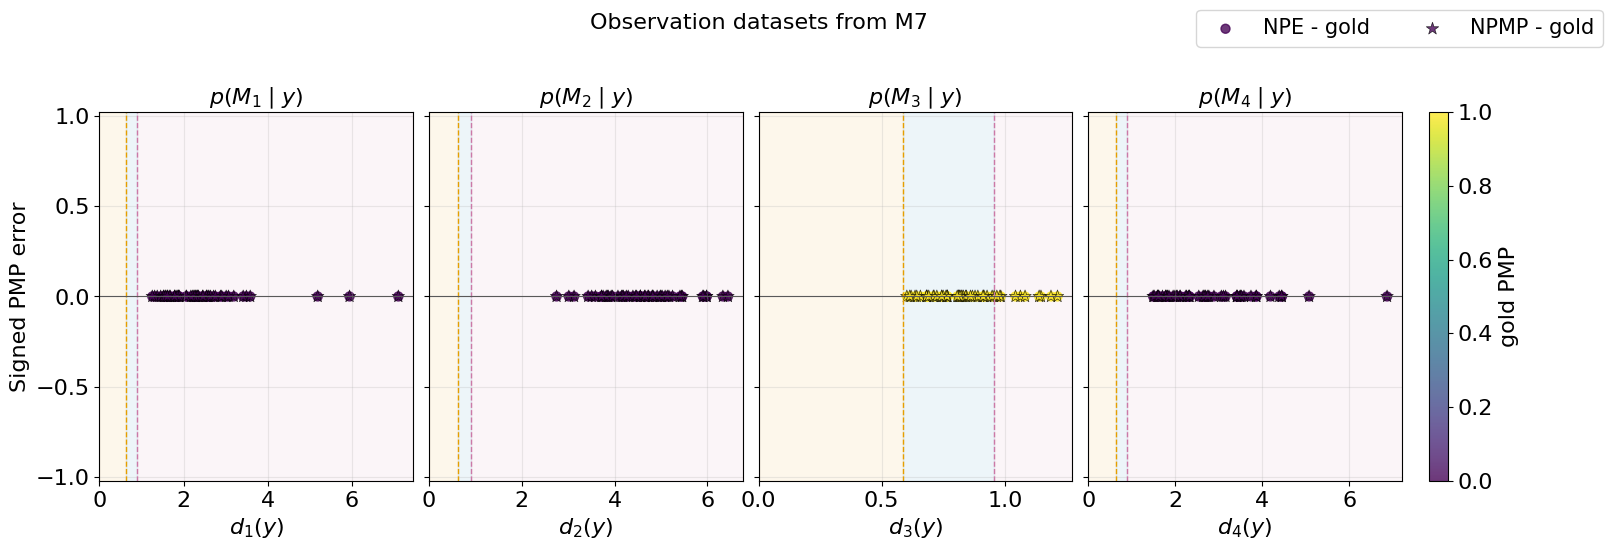

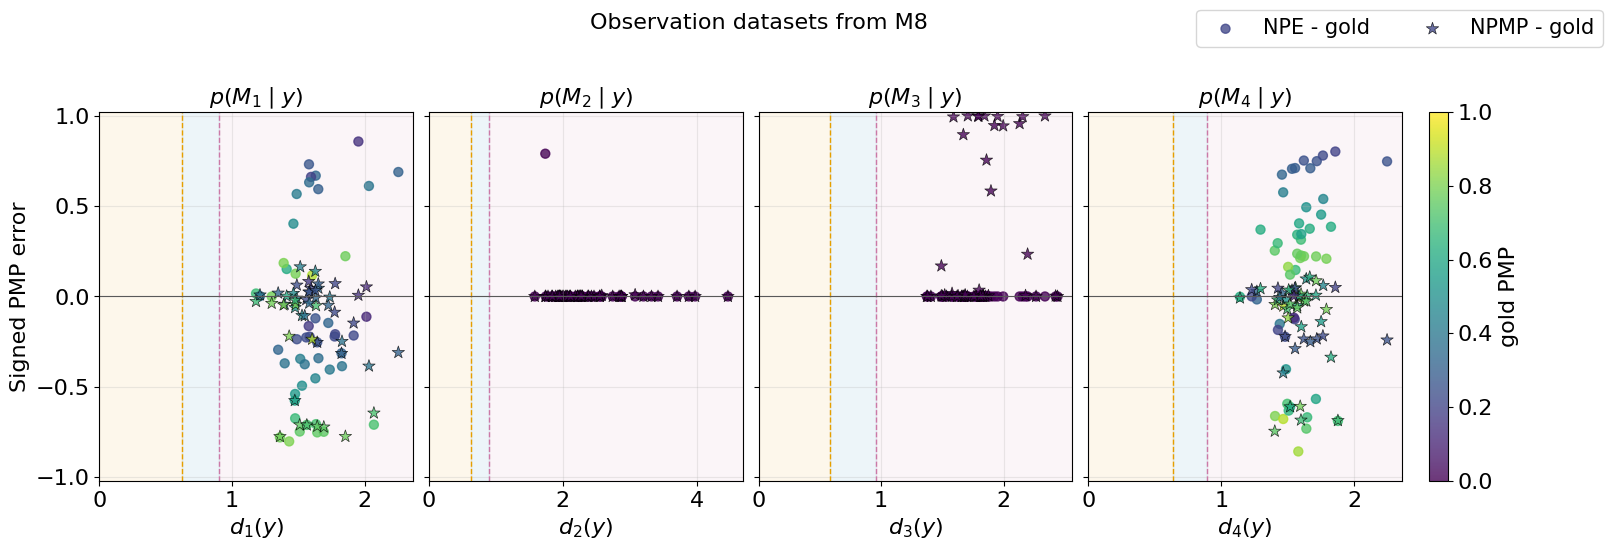

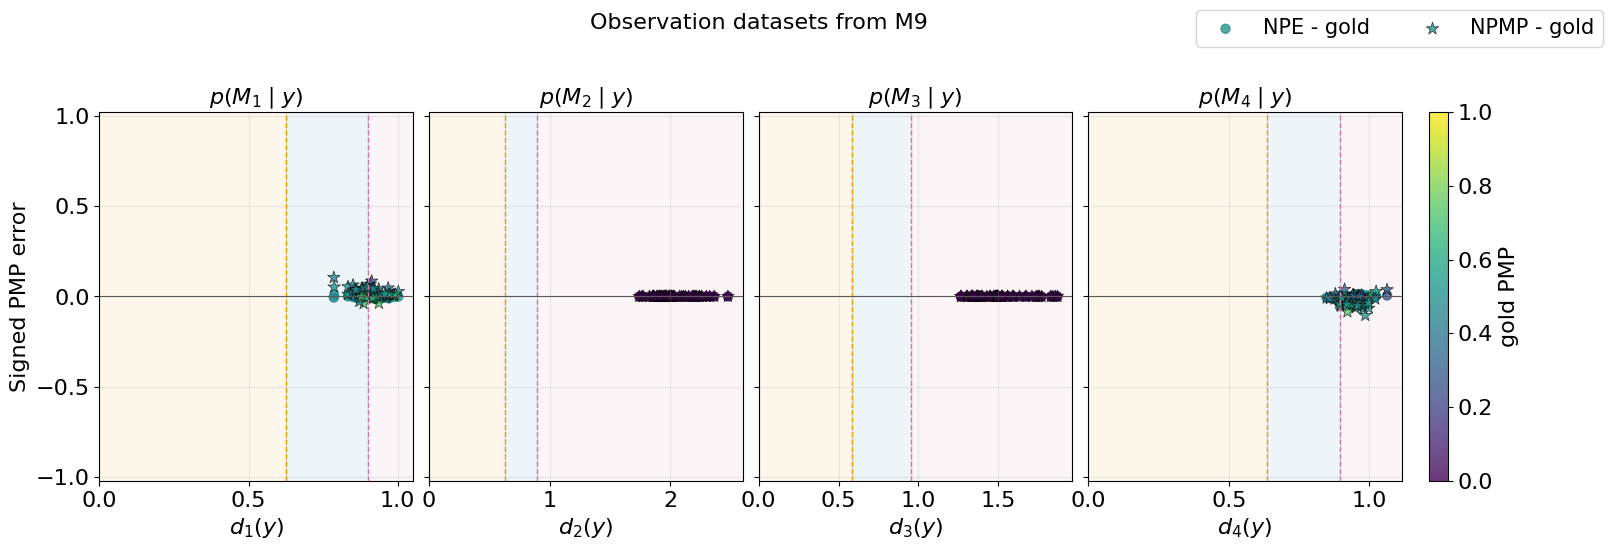

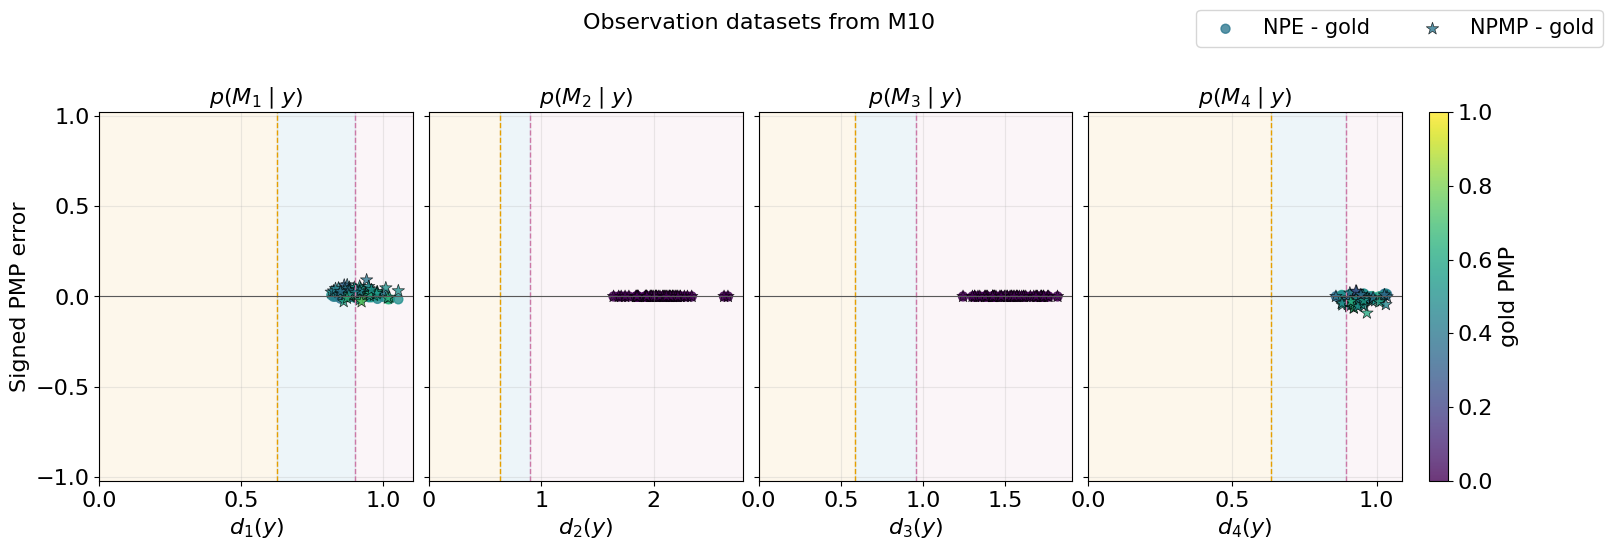

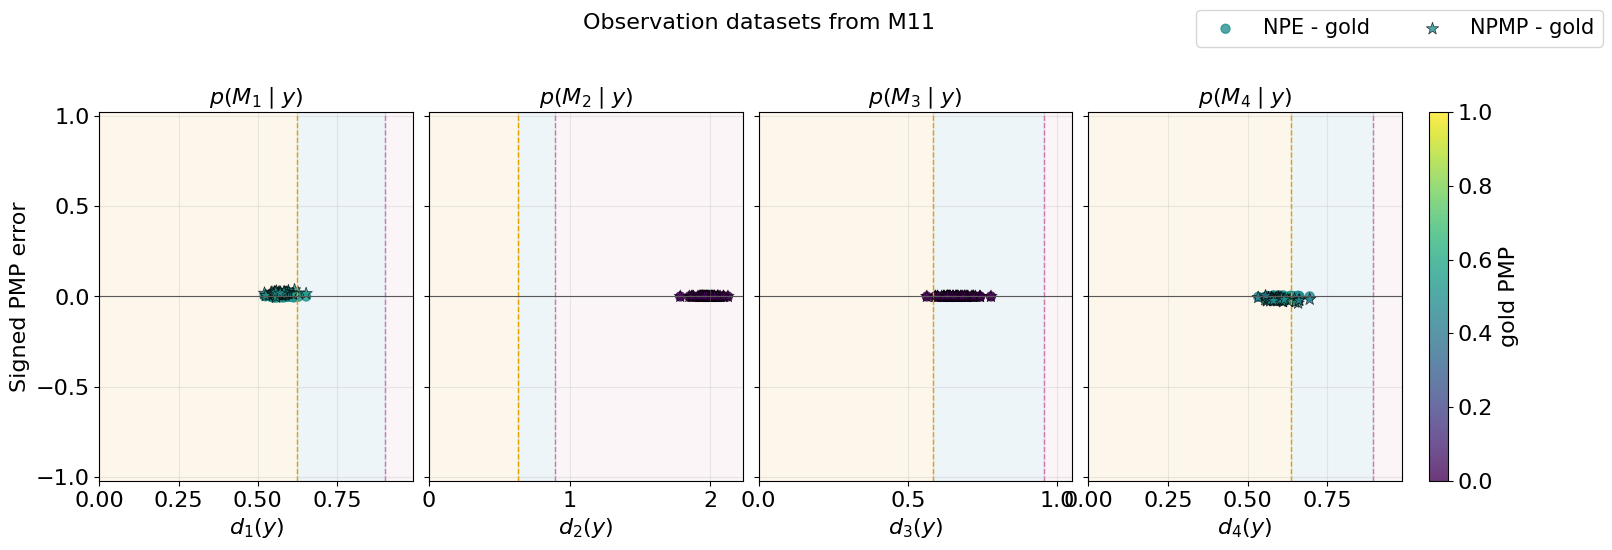

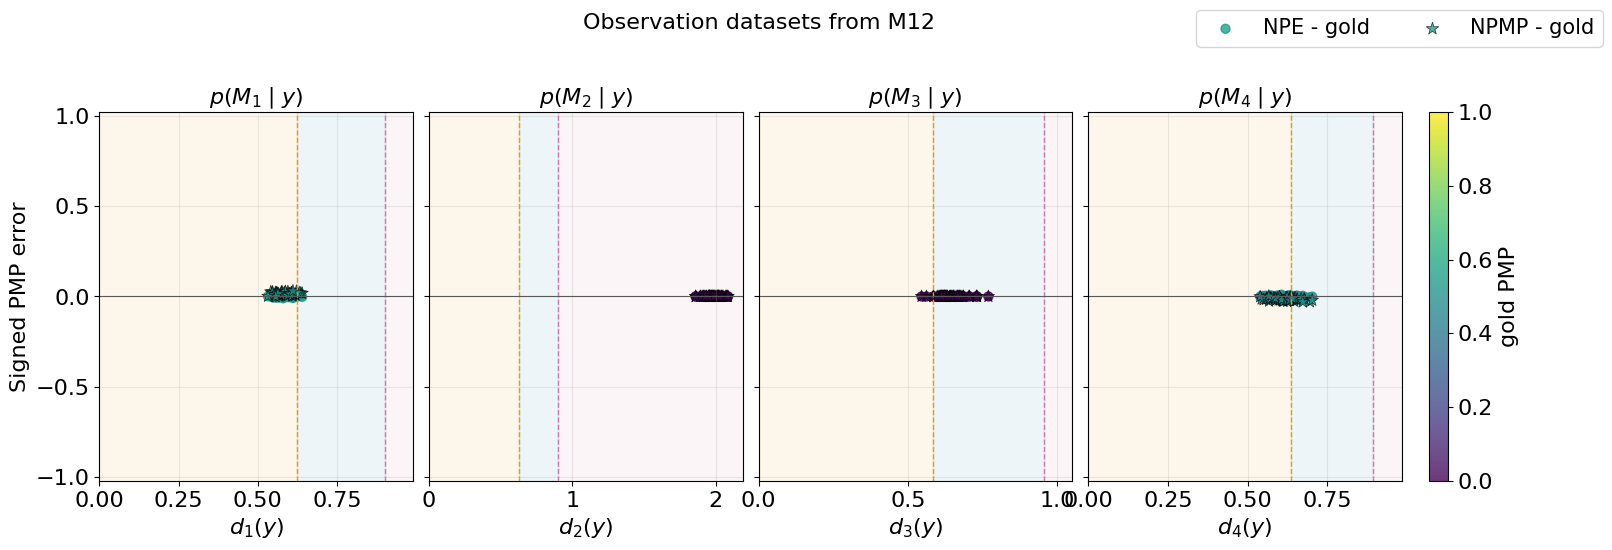

In [41]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)